In [ ]:
# Google Colab only (does nothing elsewhere): fetch the bundle next to this notebook and install pPXF.
import os, sys, subprocess
os.environ.setdefault("OMP_NUM_THREADS", "1"); os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")     # one core on Colab / Binder
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ppxf", "fitsio", "ipywidgets"], check=True)
    if not os.path.exists("interbars_students"):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/EdoBorsato/INTERBARS_classes"], check=True)
    os.chdir("interbars_students/notebooks"); print("Colab: working in", os.getcwd())

# Lecture 2b — A Seyfert 1: broad lines and the mass of a black hole

Your system has something the others do not: in **NGC 1346** we look straight into the nucleus, past the dusty
torus, and see gas orbiting the black hole at thousands of km/s (lecture 1: type 1 vs type 2). Its Hα and Hβ
have **broad wings** under the narrow lines. Today you will

1. download and prepare the spectra, as everyone else (sections 1–5);
2. fit them with narrow lines only and **see** what is missing;
3. add a **broad component** to the model, and test whether it is real;
4. use the width and the luminosity of the broad Hα to **weigh the black hole**;
5. put the narrow lines on the BPT diagram with the rest of the class — and see why the BPT alone would
   not have told you this is an AGN.

In [1]:
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):    # one BLAS thread: on Binder / Colab the pod has
    os.environ.setdefault(_v, "1")                                          # one core and multi-threaded BLAS is 30x slower
import io, sys, json
from pathlib import Path
import numpy as np, pandas as pd, requests, fitsio
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from ppxf.ppxf import ppxf

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
os.environ.setdefault("DESI_SPECTRO_REDUX", str(ROOT / "output" / "desi_redux"))
import lecture_tools as LT                # readers, pPXF input preparation, line fluxes, the BPT frame
import run_ppxf as RP                     # the project's spectrum inventory and production fit
import bpt_comparison as BC               # the SDSS comparison populations (pairs, barred galaxies)
import plot_bpt_ppxf as PB                # the sample's BPT plotting
DL = ROOT / "output" / "downloads"; DL.mkdir(parents=True, exist_ok=True)
(ROOT / "output" / "notebooks").mkdir(parents=True, exist_ok=True)       # where your results table is saved
ONLINE = True            # False = never touch the network: every spectrum, image and catalogue is already in the course folder
NET_TIMEOUT = 15         # seconds; after the first failed request the notebook switches itself to offline mode
C_KMS = 299792.458
COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
STAGE = {0: "pre-interaction", 1: "merger", 2: "post-merger"}
plt.rcParams.update({"figure.dpi": 100})
targets = pd.read_csv(ROOT / "dataset/catalogs/interbars_targets.csv").set_index("system").drop(LT.COURSE_EXCLUDE, errors="ignore")
specz = pd.read_csv(ROOT / "dataset/catalogs/interbars_specz.csv").set_index("system")
inventory = LT.inventory()
print("repo:", ROOT, "| pPXF", __import__("ppxf").__version__)

repo: /home/eborsato/PyAutoThings/workspace/interbars | pPXF 9.5.0


## 1. The sample, and your system

27 systems: barred galaxies at $z \approx 0.01$–$0.05$, most with a companion. `class_VC` is the interaction
stage from a visual classification of the images: **0** = pre-interaction (two separate galaxies), **1** =
merger (in contact, tidal bridges), **2** = post-merger (one disturbed remnant). `comp_name` is the companion.

In [2]:
cols = ["z_hand", "class_VC", "comp_name", "comp_z_hand"]
tab = targets[cols].copy(); tab["stage"] = tab.class_VC.map(STAGE)
tab["spectra"] = [", ".join(f"{r.role}:{r.source}" for r in inventory[inventory.system == s].itertuples()) for s in tab.index]
print(tab.round(4).to_string())

                        z_hand  class_VC                 comp_name  comp_z_hand            stage                          spectra
system                                                                                                                           
LEDA181851              0.0207       2.0                       NaN          NaN      post-merger             main:DESI, main:SDSS
2MASXJ09551395+1417576  0.0242       0.0                 PGC028602       0.0244  pre-interaction             main:SDSS, comp:SDSS
IC3378                  0.0453       0.0                    IC3379       0.0452  pre-interaction  main:DESI, main:SDSS, comp:SDSS
2MASXJ11422226+0845548  0.0219       1.0                    IC0720       0.0216           merger             main:SDSS, comp:SDSS
NVSSJ084256+133826      0.0168       1.0  [WGB2006] 084012+13500 b       0.0163           merger                        main:SDSS
IC2810                  0.0340       0.0                   IC2810B       0.0339  pre-inter

You chose **MCG-01-09-041**: a pair whose companion, **NGC 1346**, hosts a Seyfert 1. The steps up to the
fit are the same as in the main notebook; from section 6 on, this notebook adds what a type 1 AGN needs.
**Slow or no internet?** Set `ONLINE = False` in the first code cell: everything is in the course folder.

In [3]:
MY_SYSTEMS = ["MCG-01-09-041"]                  # <-- your system(s), e.g. ["UGC6142"], ["NGC2864"], ["IC2810", "Z44-80"]
for s_ in MY_SYSTEMS:
    r = targets.loc[s_]
    print(f"{s_}: RA {r.ra:.5f}  Dec {r.dec:.5f}  z = {r.z_hand:.4f}  stage {r.class_VC:.0f} ({STAGE.get(r.class_VC, '?')})"
          + (f";  companion {r.comp_name} at {specz.loc[s_, 'comp_sep_kpc']:.0f} kpc, Δv = {specz.loc[s_, 'dv_comp_kms']:+.0f} km/s" if isinstance(r.comp_name, str) else ";  no companion"))
BROAD_LINE = {"MCG-01-09-041"}                # systems with a broad-line (Seyfert 1) nucleus
if BROAD_LINE & set(MY_SYSTEMS):
    print("\n>>> Your selection includes a Seyfert 1: continue in L2b_broad_lines.ipynb <<<")
mine = inventory[inventory.system.isin(MY_SYSTEMS)]
print(); print(mine[["system", "role", "source", "spec_id", "z_in"]].to_string())

MCG-01-09-041: RA 52.53971  Dec -5.52167  z = 0.0139  stage 1 (merger);  companion NGC1346 at 27 kpc, Δv = -166 km/s

>>> Your selection includes a Seyfert 1: continue in L2b_broad_lines.ipynb <<<

                                system  role source        spec_id      z_in
label                                                                       
MCG-01-09-041_sdss       MCG-01-09-041  main   SDSS  461-51910-367  0.013916
MCG-01-09-041_comp_sdss  MCG-01-09-041  comp   SDSS  461-51910-361  0.013365


## 2. Find the spectra in the archives

Spectroscopic surveys publish **catalogues** — one row per spectrum, with position, redshift and quality —
that can be queried in SQL (the ADQL dialect) over the web. Both SDSS DR17 and DESI DR1 are served by the
NOIRLab **Astro Data Lab**. We ask for every spectrum within 30″ of each of your galaxies.

In [4]:
def datalab(sql):
    if not ONLINE:
        raise ConnectionError("offline mode")
    r = requests.post("https://datalab.noirlab.edu/tap/sync", data=dict(REQUEST="doQuery", LANG="ADQL", FORMAT="csv", QUERY=sql), timeout=NET_TIMEOUT)
    r.raise_for_status(); return pd.read_csv(io.StringIO(r.text))
R = 30 / 3600
for s_ in MY_SYSTEMS:
    ra_, dec_ = float(targets.loc[s_, "ra"]), float(targets.loc[s_, "dec"]); dra = R / np.cos(np.radians(dec_))
    box = lambda rc, dc: f"{rc} BETWEEN {ra_ - dra} AND {ra_ + dra} AND {dc} BETWEEN {dec_ - R} AND {dec_ + R}"
    try:
        sdss = datalab(f"SELECT plate, mjd, fiberid, ra, dec, z, zwarning, class FROM sdss_dr17.specobj WHERE {box('ra', 'dec')}")
        desi = datalab(f"SELECT targetid, mean_fiber_ra AS ra, mean_fiber_dec AS dec, z, zwarn, spectype, survey, program, healpix, zcat_primary FROM desi_dr1.zpix WHERE {box('mean_fiber_ra', 'mean_fiber_dec')}")
        for name, d in (("SDSS DR17", sdss), ("DESI DR1", desi)):
            d["sep_arcsec"] = 3600 * np.hypot((d.ra - ra_) * np.cos(np.radians(dec_)), d.dec - dec_)
            print(f"== {s_} / {name}: {len(d)} spectra within 30\""); print(d.sort_values("sep_arcsec").round(5).to_string(index=False) if len(d) else "   none"); print()
    except Exception as e:
        if ONLINE: print(f"archive not reachable ({e.__class__.__name__}): switching to offline mode"); ONLINE = False
        print(f"{s_}: the same search, saved in the course folder:")
        m = pd.read_csv(ROOT / "dataset/catalogs/specz_matches.csv"); print(m[(m.system == s_) & (m.sep_arcsec < 30) & m.survey.isin(["SDSS DR17", "DESI DR1"])][["survey", "obj_id", "z", "sep_arcsec"]].to_string(index=False))

== MCG-01-09-041 / SDSS DR17: 1 spectra within 30"
 plate   mjd  fiberid       ra      dec       z  zwarning  class  sep_arcsec
   461 51910      367 52.53969 -5.52167 0.01392         0 GALAXY     0.08255

== MCG-01-09-041 / DESI DR1: 0 spectra within 30"
   none



Things to notice: a galaxy can appear several times (DESI observes some targets in more than one
program — `zcat_primary` marks the best spectrum); rows tens of arcseconds away are other galaxies,
often the companion; `zwarning` / `zwarn` = 0 means the pipeline trusts its redshift.

## 3. Download

**SDSS** stores one small FITS file per spectrum (~200 kB), at an address built from the plate, MJD and fibre
numbers. We download it from the SDSS Science Archive Server (SAS).

**DESI** stores spectra in *healpix coadds*: one file per patch of sky, holding all the targets in it (200–500
MB each). Downloading a whole coadd per student is not practical in class, so the course bundle ships a
copy trimmed to our galaxies (same format, ~1 MB). The cell prints the address of the full public file, so
you can see where it comes from.

In [5]:
SAS = "https://data.sdss.org/sas/dr17"
def download_sdss(label):
    r = inventory.loc[label]; name = Path(r.file).name; p, mj, f = name[5:-5].split("-"); dst = DL / name
    if dst.exists() and dst.stat().st_size > 1e5:
        return dst
    if not ONLINE:
        print(f"   offline mode: using the copy in the course folder ({name})"); return Path(r.file)
    urls = [f"{SAS}/{s}/spectro/redux/{run2d}/spectra/lite/{p}/{name}" for s, run2d in
            [("sdss", r.run2d), ("eboss", r.run2d), ("sdss", "26"), ("sdss", "103"), ("sdss", "104"), ("eboss", "v5_13_2")] if isinstance(run2d, str) and run2d]
    for u in urls:
        try:
            resp = requests.get(u, timeout=NET_TIMEOUT)
        except requests.RequestException:
            globals()["ONLINE"] = False; print("   SDSS server not reachable: switching to offline mode"); break
        if resp.ok and resp.content[:6] == b"SIMPLE":
            dst.write_bytes(resp.content); print(f"   downloaded {u}  ({len(resp.content) / 1e3:.0f} kB)"); return dst
    print(f"   {name}: download failed (offline?) - using the copy in the course bundle"); return Path(r.file)

FILES = {}
for lab, r in mine.iterrows():
    print(f"{lab} ({r.source}):")
    if r.source == "SDSS":
        FILES[lab] = download_sdss(lab)
    else:
        rel = Path(r.file).as_posix().split("iron/healpix/")[1]
        print(f"   full public coadd: https://data.desi.lbl.gov/public/dr1/spectro/redux/iron/healpix/{rel}\n   using the trimmed copy in the bundle: {Path(r.file).name}, TARGETID {r.spec_id}")
        FILES[lab] = Path(r.file)

MCG-01-09-041_sdss (SDSS):
MCG-01-09-041_comp_sdss (SDSS):


Look inside a file: a FITS file is a list of *HDUs* (header + data). An SDSS "lite" file has the spectrum
in the `COADD` table (`loglam` = log₁₀ wavelength, `flux` in 10⁻¹⁷ erg s⁻¹ cm⁻² Å⁻¹, `ivar` = 1/σ², `wdisp` =
the instrumental line width); a DESI coadd has, per spectrograph arm (B, R, Z), the wavelength, flux, inverse
variance, mask and resolution matrix, and a `FIBERMAP` table saying which row is which target.

In [6]:
for lab, f in FILES.items():
    with fitsio.FITS(f) as F:
        print(f"{lab}: {f.name}"); print("   HDUs:", [h.get_extname() or "(primary)" for h in F][:20])

MCG-01-09-041_sdss: spec-0461-51910-0367.fits
   HDUs: ['(primary)', 'COADD', 'SPECOBJ', 'SPZLINE']
MCG-01-09-041_comp_sdss: spec-0461-51910-0361.fits
   HDUs: ['(primary)', 'COADD', 'SPECOBJ', 'SPZLINE']


### Where did the fibre land?

A fibre spectrum sees only a small disc on the sky — 3″ for SDSS, 1.5″ for DESI. Here it is on a Legacy
Survey colour image of your galaxy (saved in the course folder).

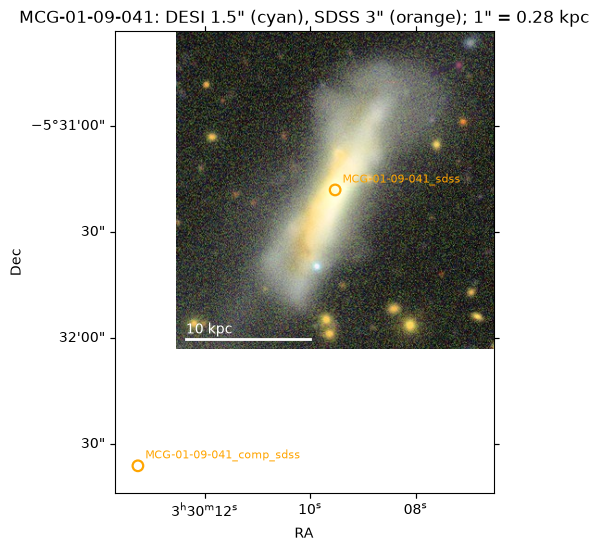

In [7]:
from astropy.wcs import WCS
from PIL import Image
def ls_cutout(ra, dec, size=60.0, pix=0.262):
    name = f"ls_{ra:.5f}_{dec:.5f}_{size:.0f}_{pix}.jpg"
    f = ROOT / "dataset" / "cutouts" / name                                  # shipped with the course folder
    if not f.exists():
        f = ROOT / "output" / "notebooks" / name; f.parent.mkdir(parents=True, exist_ok=True)
    if not f.exists():
        if not ONLINE:
            raise ConnectionError("offline mode and no saved image")
        r = requests.get("https://www.legacysurvey.org/viewer/jpeg-cutout", params=dict(ra=ra, dec=dec, layer="ls-dr10", pixscale=pix, size=int(size / pix)), timeout=NET_TIMEOUT)
        r.raise_for_status(); f.write_bytes(r.content)
    im = np.flipud(np.asarray(Image.open(f)))
    w = WCS(naxis=2); w.wcs.ctype = ["RA---TAN", "DEC--TAN"]; w.wcs.crval = [ra, dec]; w.wcs.crpix = [(im.shape[1] + 1) / 2, (im.shape[0] + 1) / 2]; w.wcs.cdelt = [-pix / 3600, pix / 3600]
    return im, w
for s_ in MY_SYSTEMS:
    try:
        ra_, dec_, z_ = float(targets.loc[s_, "ra"]), float(targets.loc[s_, "dec"]), float(targets.loc[s_, "z_hand"]); kpc = 1 / COSMO.arcsec_per_kpc_proper(z_).value
        im, w = ls_cutout(ra_, dec_, 90.0)
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection=w)); ax.imshow(im, origin="lower")
        for lab, r in inventory[inventory.system == s_].iterrows():
            if r.source == "DESI":
                fm = fitsio.read(r.file, "FIBERMAP"); fm = fm[fm["TARGETID"] == int(r.spec_id)][0]; xy, d_, c_ = (fm["MEAN_FIBER_RA"], fm["MEAN_FIBER_DEC"]), 1.5, "cyan"
            else:
                h = fitsio.read_header(FILES.get(lab, r.file), 0); xy, d_, c_ = (h["PLUG_RA"], h["PLUG_DEC"]), 3.0, "orange"
            x, y = w.world_to_pixel_values(*xy); ax.add_patch(plt.Circle((x, y), d_ / 2 / 0.262, fill=False, color=c_, lw=1.6)); ax.text(x + 8, y + 8, lab, color=c_, fontsize=8)
        ax.plot([10, 10 + 10 / kpc / 0.262], [10, 10], color="w", lw=2); ax.text(10, 16, "10 kpc", color="w")
        ax.set(xlabel="RA", ylabel="Dec", title=f"{s_}: DESI 1.5\" (cyan), SDSS 3\" (orange); 1\" = {kpc:.2f} kpc"); plt.show()
    except Exception as e:
        print(f"{s_}: no image ({e.__class__.__name__}: offline?)")

The fibre covers the **nucleus** only — the central kiloparsec or two. The bar, the disc and the tidal
features are outside it: everything below is about the nucleus.

## 4. Look at the spectrum

We start with NGC 1346, the companion (`MCG-01-09-041_comp_sdss`). The readers return the same five arrays for both surveys: vacuum wavelength [Å], flux and inverse variance,
the instrumental FWHM at each pixel [Å] (from the DESI resolution matrix or the SDSS `wdisp`), and a mask of
bad pixels. The spectrum is in the **observed** frame: the lines sit at $\lambda_{\rm rest}(1+z)$.

MCG-01-09-041_comp_sdss: SDSS, z = 0.01337, 3819-9215 Å, 3827 good pixels, instrumental FWHM 2.84 Å


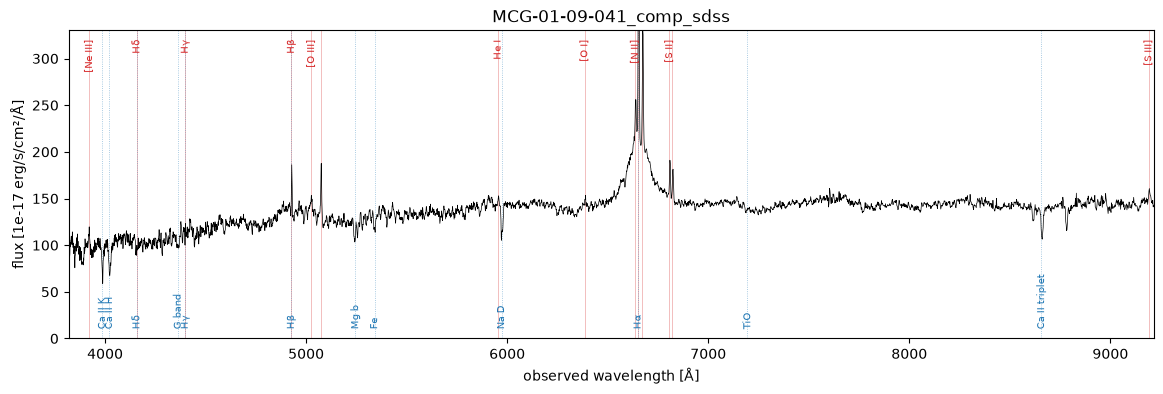

In [8]:
LABEL = "MCG-01-09-041_comp_sdss"         # NGC 1346, the Seyfert 1; the other spectrum is "MCG-01-09-041_sdss"
r = inventory.loc[LABEL]
lam_v, flux, ivar, fwhm, mask = RP.read_desi(r.file, r.spec_id) if r.source == "DESI" else RP.read_sdss(FILES[LABEL])
z = float(r.z_in); good = (ivar > 0) & ~mask
print(f"{LABEL}: {r.source}, z = {z:.5f}, {lam_v[0]:.0f}-{lam_v[-1]:.0f} Å, {good.sum()} good pixels, instrumental FWHM {np.median(fwhm[good]):.2f} Å")
fig, ax = plt.subplots(figsize=(14, 4)); ax.plot(lam_v, np.where(good, flux, np.nan), color="k", lw=0.5)
ax.set(xlim=(lam_v[0], lam_v[-1]), ylim=(0, np.nanpercentile(np.where(good, flux, np.nan), 99.7) * 1.3), xlabel="observed wavelength [Å]", ylabel="flux [1e-17 erg/s/cm²/Å]", title=LABEL)
LT.annotate(ax, z=z); plt.show()

## 5. Prepare the pPXF inputs

Everything from lecture 1, Part 1, in one function (`LT.prepare`, the same steps as the production script
`scripts/run_ppxf.py`):

* **air wavelengths**: the E-MILES templates are tabulated in air, the surveys in vacuum (forgetting it
  shifts every line by ~80 km/s);
* the **logarithmic grid** (`util.log_rebin`): constant `velscale` km/s per pixel; the noise is rebinned too;
* the **stellar templates**: 25 ages × 6 metallicities, degraded to the instrumental resolution of *this*
  spectrum, normalised in the V band (weights = light fractions);
* the **gas templates**, one per line, and the **kinematic components**: 0 = stars, 1 = Balmer lines,
  2 = forbidden lines;
* the **good pixels**: everything except bad pixels, the 5577 Å sky line and the telluric A band.

In [9]:
P = LT.prepare(lam_v, flux, ivar, fwhm, mask, z)
print(f"velscale = {P['velscale']:.1f} km/s/pixel, {P['galaxy'].size} pixels ({P['goodpixels'].size} fitted), "
      f"median S/N per pixel = {np.median(P['galaxy'][P['goodpixels']] / P['noise'][P['goodpixels']]):.1f}")
print(f"{P['n_temps']} stellar templates + {len(P['gas_names'])} gas templates: {list(P['gas_names'])}")

Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[SII]6716'
 '[SII]6731' '[NeIII]3968' '[NeIII]3869' 'HeII4687' 'HeI5876'
 '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
velscale = 69.0 km/s/pixel, 3827 pixels (3757 fitted), median S/N per pixel = 43.6
150 stellar templates + 17 gas templates: [np.str_('H10'), np.str_('H9'), np.str_('H8'), np.str_('Heps'), np.str_('Hdelta'), np.str_('Hgamma'), np.str_('Hbeta'), np.str_('Halpha'), np.str_('[SII]6716'), np.str_('[SII]6731'), np.str_('[NeIII]3968'), np.str_('[NeIII]3869'), np.str_('HeII4687'), np.str_('HeI5876'), np.str_('[OIII]5007_d'), np.str_('[OI]6300_d'), np.str_('[NII]6583_d')]


## 6. A first fit: narrow lines only

Exactly the fit everyone else runs: stars, plus narrow Balmer and forbidden lines (σ < 500 km/s).

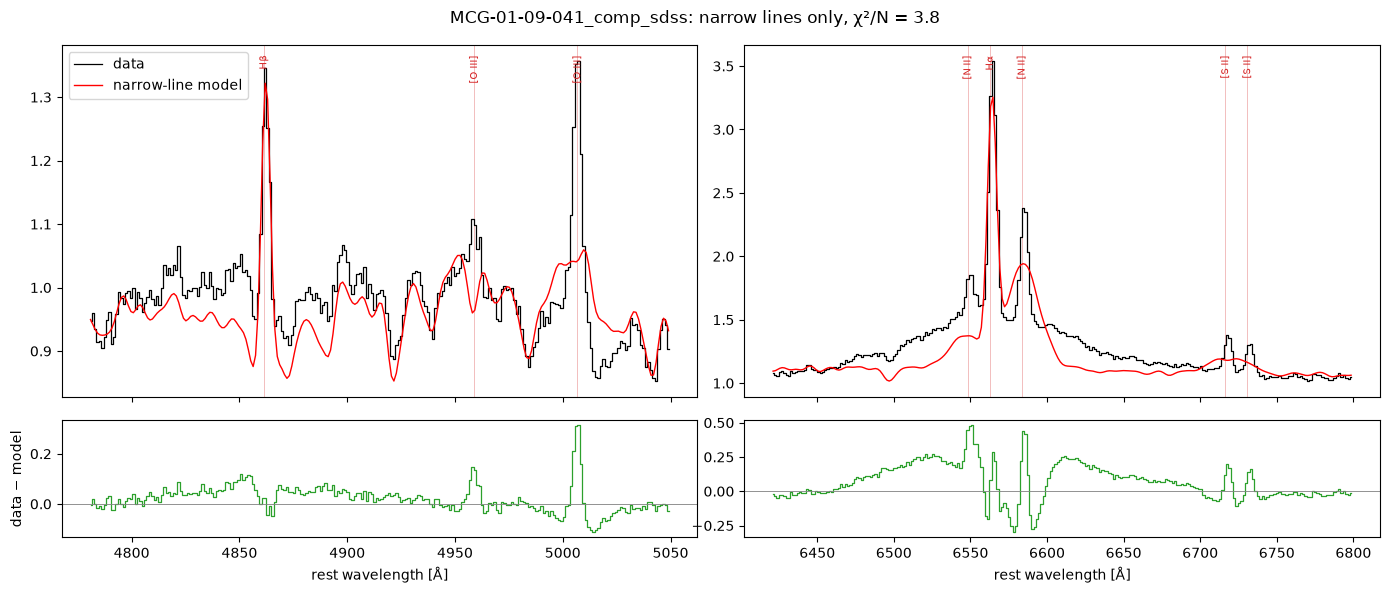

In [10]:
pp = ppxf(P["templates"], P["galaxy"], P["noise"], P["velscale"], P["start"], moments=[2, 2, 2], degree=-1, mdegree=10,
          lam=P["lam_gal"], lam_temp=P["sps"].lam_temp, component=P["component"], gas_component=np.array(P["component"]) > 0,
          gas_names=P["gas_names"], goodpixels=P["goodpixels"], bounds=P["bounds"], quiet=True)
rest = P["lam_gal"] / (1 + z)
fig, axs = plt.subplots(2, 2, figsize=(14, 6), sharex="col", gridspec_kw=dict(height_ratios=[3, 1]))
for k, (lo, hi) in enumerate([(4780, 5050), (6420, 6800)]):
    s = (rest > lo) & (rest < hi)
    axs[0, k].plot(rest[s], P["galaxy"][s], "k", lw=0.9, drawstyle="steps-mid", label="data"); axs[0, k].plot(rest[s], pp.bestfit[s], "r", lw=1, label="narrow-line model")
    axs[1, k].plot(rest[s], (P["galaxy"] - pp.bestfit)[s], color="tab:green", lw=0.9, drawstyle="steps-mid"); axs[1, k].axhline(0, color="0.5", lw=0.6)
    axs[1, k].set_xlabel("rest wavelength [Å]"); LT.annotate(axs[0, k], kinds=("emission",), fontsize=7)
axs[0, 0].legend(); axs[1, 0].set_ylabel("data − model"); fig.suptitle(f"{LABEL}: narrow lines only, χ²/N = {pp.chi2:.1f}"); fig.tight_layout(); plt.show()

Look at the residuals (green): under Hα, and more weakly under Hβ, there is a **broad hump** that no narrow
line can fit — flux spread over ±100 Å, i.e. ±5000 km/s. The χ² per pixel is far above 1. The narrow-line model
is missing a component.

## 7. Add a broad component

In pPXF this is one more **kinematic component**: a second copy of the Balmer-line templates (Hα, Hβ, Hγ, …)
with its own velocity and a width allowed between 500 and 5000 km/s. Everything else stays the same.

A broad component *always* lowers χ² a little — it can soak up any imperfection of the continuum. So we adopt it
only if it passes four tests: χ² drops by more than 25; the broad Hα has S/N > 5; its width is not stuck at a
bound; and its flux is at least 30 % of the narrow Hα.

Δχ² = 10538   broad Hα S/N = 128   σ_broad = 2704 km/s   broad / narrow Hα = 4.7
-> BROAD COMPONENT ADOPTED


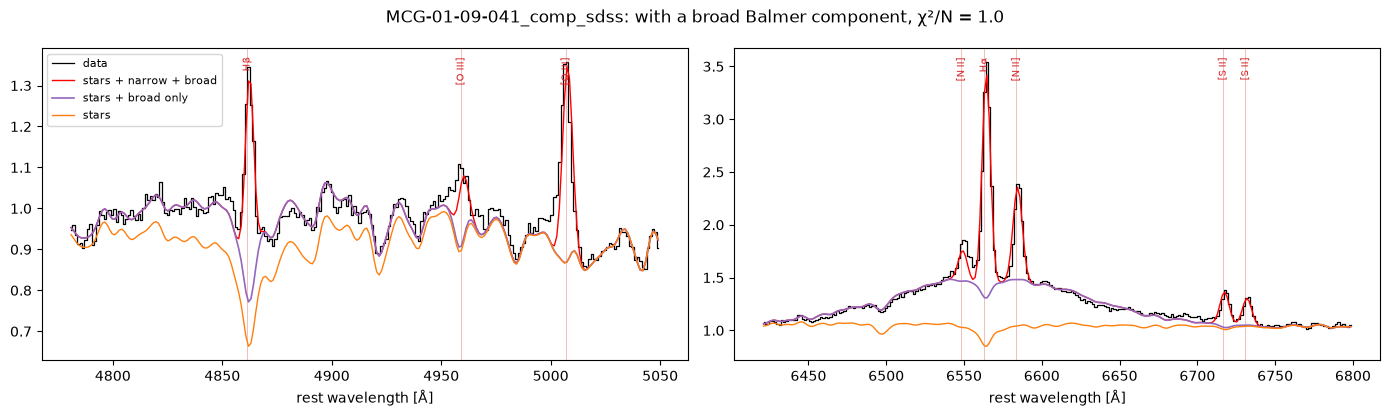

In [11]:
def fit_broad(P):
    ng = len(P["gas_names"]); balmer = np.array(["[" not in n for n in P["gas_names"]])
    tpl = np.column_stack([P["templates"], P["templates"][:, -ng:][:, balmer]])
    comp = list(P["component"]) + [3] * int(balmer.sum())
    names = np.concatenate([P["gas_names"], [n + "_broad" for n in P["gas_names"][balmer]]])
    vel = P["start"][0][0]
    pp_b = ppxf(tpl, P["galaxy"], P["noise"], P["velscale"], P["start"] + [[vel, 1500.0]], moments=[2, 2, 2, 2], degree=-1, mdegree=10,
                lam=P["lam_gal"], lam_temp=P["sps"].lam_temp, component=comp, gas_component=np.array(comp) > 0, gas_names=names,
                goodpixels=P["goodpixels"], bounds=P["bounds"] + [[[vel - 3000, vel + 3000], [500, 5000]]], quiet=True)
    return pp_b, names

def broad_tests(pp, pp_b, names, P):
    ib, ibb = list(names).index("Halpha"), list(names).index("Halpha_broad")
    t = dict(dchi2=(pp.chi2 - pp_b.chi2) * len(P["goodpixels"]), snr=pp_b.gas_flux[ibb] / pp_b.gas_flux_error[ibb],
             sigma=pp_b.sol[3][1], ratio=pp_b.gas_flux[ibb] / pp_b.gas_flux[ib])
    t["adopt"] = bool(t["dchi2"] > 25 and t["snr"] > 5 and 600 < t["sigma"] < 4500 and t["ratio"] > 0.3)
    return t

pp_b, names_b = fit_broad(P); T = broad_tests(pp, pp_b, names_b, P)
print(f"Δχ² = {T['dchi2']:.0f}   broad Hα S/N = {T['snr']:.0f}   σ_broad = {T['sigma']:.0f} km/s   broad / narrow Hα = {T['ratio']:.1f}")
print("->", "BROAD COMPONENT ADOPTED" if T["adopt"] else "broad component rejected")
broad_idx = [i for i, n in enumerate(names_b) if n.endswith("_broad")]
broad_model = pp_b.gas_bestfit_templates[:, broad_idx].sum(1)
fig, axs = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, (lo, hi) in zip(axs, [(4780, 5050), (6420, 6800)]):
    s = (rest > lo) & (rest < hi); stars_b = pp_b.bestfit - pp_b.gas_bestfit
    ax.plot(rest[s], P["galaxy"][s], "k", lw=0.9, drawstyle="steps-mid", label="data"); ax.plot(rest[s], pp_b.bestfit[s], "r", lw=1, label="stars + narrow + broad")
    ax.plot(rest[s], (stars_b + broad_model)[s], color="tab:purple", lw=1.2, label="stars + broad only"); ax.plot(rest[s], stars_b[s], color="tab:orange", lw=1, label="stars")
    ax.set_xlabel("rest wavelength [Å]"); LT.annotate(ax, kinds=("emission",), fontsize=7)
axs[0].legend(fontsize=8); fig.suptitle(f"{LABEL}: with a broad Balmer component, χ²/N = {pp_b.chi2:.1f}"); fig.tight_layout(); plt.show()

## 8. Weighing the black hole

The broad-line clouds orbit the black hole, so their speed and their distance give its mass, as for a planet
around a star: $M_{\rm BH} \sim R\,v^2/G$. The speed comes from the **width** of the broad line. The distance
comes from its **luminosity**: reverberation mapping (timing how long the broad lines take to echo changes of
the continuum) showed that the size of the broad-line region grows with the AGN luminosity, roughly as
$R \propto L^{1/2}$. Greene & Ho (2005, ApJ 630, 122) calibrated the result for the broad Hα line alone:

$$
M_{\rm BH} \approx 2.0\times10^{6}\,M_\odot \left(\frac{L_{{\rm H}\alpha,\,{\rm broad}}}{10^{42}\ {\rm erg\,s^{-1}}}\right)^{0.55}
\left(\frac{{\rm FWHM}_{{\rm H}\alpha,\,{\rm broad}}}{10^{3}\ {\rm km\,s^{-1}}}\right)^{2.06}
$$

The FWHM of a Gaussian is $2.355\,\sigma$; pPXF's σ already has the instrumental width removed. These
"single-epoch" masses are uncertain by about a factor of 2–3 (0.3–0.5 dex).

In [12]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
ibb = list(names_b).index("Halpha_broad"); dlam = 6562.8 * (1 + z) * P["velscale"] / C_KMS
F_broad = pp_b.gas_flux[ibb] * dlam * P["norm"] * 1e-17                          # erg/s/cm²
d_L = FlatLambdaCDM(H0=70, Om0=0.3).luminosity_distance(z).to(u.cm).value
L_broad = 4 * np.pi * d_L ** 2 * F_broad
fwhm_broad = 2.355 * pp_b.sol[3][1]
M_bh = 2.0e6 * (L_broad / 1e42) ** 0.55 * (fwhm_broad / 1e3) ** 2.06
print(f"broad Hα: flux {F_broad:.2e} erg/s/cm², distance {d_L / 3.086e24:.0f} Mpc, luminosity {L_broad:.2e} erg/s, FWHM {fwhm_broad:.0f} km/s")
print(f"black-hole mass ≈ {M_bh:.1e} M☉   (log M = {np.log10(M_bh):.2f} ± ~0.4)")

broad Hα: flux 9.54e-14 erg/s/cm², distance 58 Mpc, luminosity 3.82e+40 erg/s, FWHM 6369 km/s
black-hole mass ≈ 1.5e+07 M☉   (log M = 7.18 ± ~0.4)


Compare: the Milky Way's black hole has $4\times10^6\,M_\odot$. The light we see comes only from the nucleus
inside the fibre; if part of it is hidden by dust, the luminosity — and the mass — are underestimates.

## 9. The narrow lines on the BPT

With the broad component in the model, the narrow Hα and Hβ are measured cleanly, and the narrow-line ratios go
on the BPT like everyone else's. The loop fits every spectrum of your system, adopting a broad component
wherever it passes the tests.

In [13]:
def bpt_point(L):                                                       # line fluxes -> BPT coordinates, as in the main notebook
    x = np.log10(L.loc["nii", "flux"] / L.loc["ha", "flux"]); y = np.log10(L.loc["oiii", "flux"] / L.loc["hb", "flux"])
    ex = np.hypot(1 / L.loc["nii", "snr"], 1 / L.loc["ha", "snr"]) / np.log(10); ey = np.hypot(1 / L.loc["oiii", "snr"], 1 / L.loc["hb", "snr"]) / np.log(10)
    snr = L.loc[["ha", "hb", "oiii", "nii"], "snr"].min()
    return x, y, ex, ey, snr, (LT.bpt_class(x, y) if snr >= 3 else "low S/N")

rows = []
for lab, r in mine.iterrows():
    arrays = RP.read_desi(r.file, r.spec_id) if r.source == "DESI" else RP.read_sdss(FILES[lab])
    Pk = LT.prepare(*arrays, float(r.z_in))
    ppk = ppxf(Pk["templates"], Pk["galaxy"], Pk["noise"], Pk["velscale"], Pk["start"], moments=[2, 2, 2], degree=-1, mdegree=10,
               lam=Pk["lam_gal"], lam_temp=Pk["sps"].lam_temp, component=Pk["component"], gas_component=np.array(Pk["component"]) > 0,
               gas_names=Pk["gas_names"], goodpixels=Pk["goodpixels"], bounds=Pk["bounds"], quiet=True)
    ppb, nb = fit_broad(Pk); Tk = broad_tests(ppk, ppb, nb, Pk)
    Lk = LT.line_fluxes(ppb if Tk["adopt"] else ppk, Pk)                   # narrow lines (broad copies are not in the list)
    xk, yk, exk, eyk, snrk, clsk = bpt_point(Lk)
    rows.append(dict(label=lab, system=r.system, role=r.role, source=r.source, broad=Tk["adopt"], sigma_broad=Tk["sigma"] if Tk["adopt"] else np.nan,
                     log_nii_ha=xk, log_nii_ha_err=exk, log_oiii_hb=yk, log_oiii_hb_err=eyk, min_snr=snrk, bpt_class=clsk))
    print(f"{lab:28s} broad: {'yes' if Tk['adopt'] else 'no ':3s}  narrow lines -> {clsk:10s} ({xk:+.2f}, {yk:+.2f})")
res = pd.DataFrame(rows); res.to_csv(ROOT / "output/notebooks/my_results.csv", index=False); print("\nsaved output/notebooks/my_results.csv")

Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[SII]6716'
 '[SII]6731' '[NeIII]3968' '[NeIII]3869' 'HeII4687' 'HeI5876'
 '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']


MCG-01-09-041_sdss           broad: no   narrow lines -> SF         (-0.36, -0.44)


Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[SII]6716'
 '[SII]6731' '[NeIII]3968' '[NeIII]3869' 'HeII4687' 'HeI5876'
 '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']


MCG-01-09-041_comp_sdss      broad: yes  narrow lines -> composite  (-0.35, -0.01)

saved output/notebooks/my_results.csv


## 9. The BPT of barred galaxies and of interacting galaxies

The reference populations are ~100 000 SDSS galaxies at $z < 0.1$ with the same four lines measured by the
MPA-JHU group (Brinchmann et al. 2004), all with S/N > 3:

* **barred**: galaxies with a strong, intermediate or weak bar in the visual catalogue of **Nair & Abraham
  (2010)**;
* **interacting**: galaxies with a spectroscopic companion within **30 kpc** (projected) and **500 km/s**.

Contours enclose 20, 50 and 80 % of each population. Bars and interactions are both thought to drive gas
to the centre — to feed star formation, or the black hole. If one process fed the AGN more, its population
would have more galaxies to the right of the Kewley line.

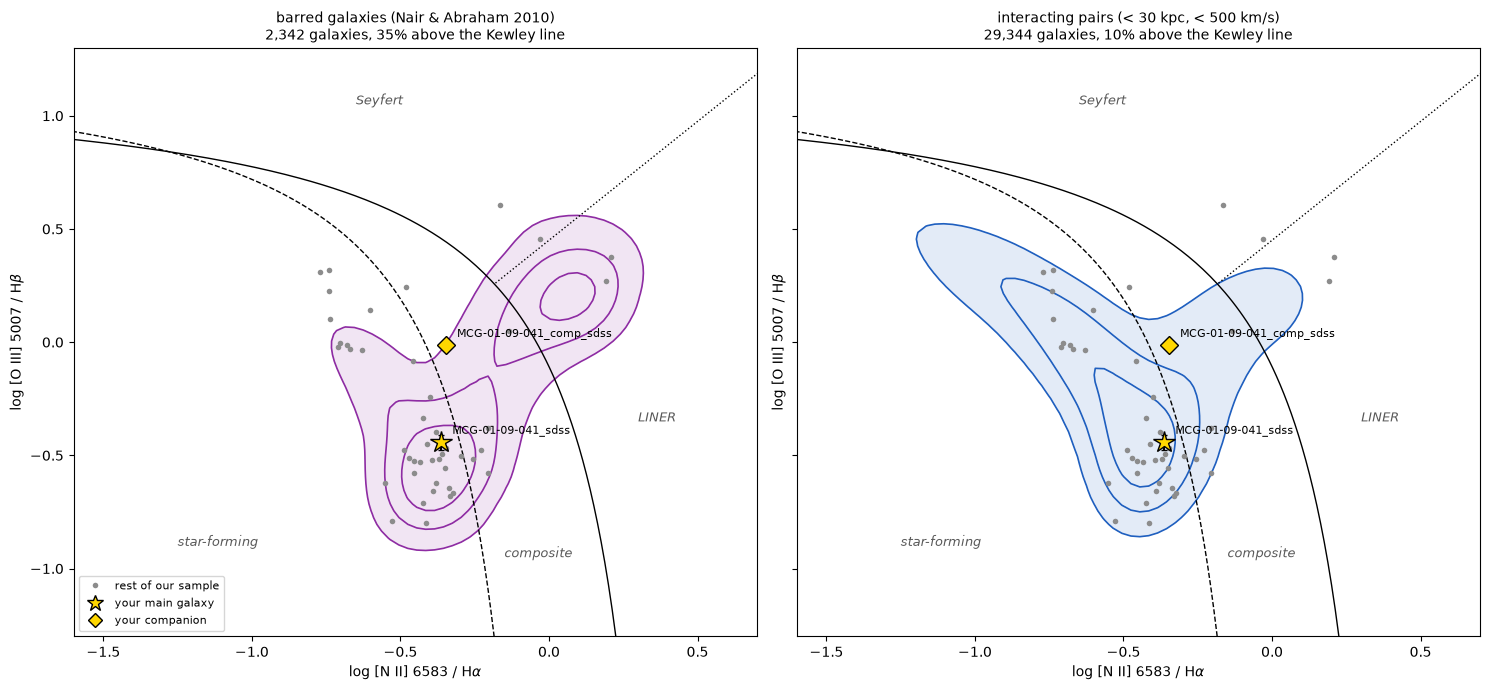

In [14]:
sdss = BC.ratios(BC.load_sdss())
sdss["pair"] = BC.sdss_pairs(sdss, 30.0, 500.0); sdss["in_nair"], sdss["bar"], sdss["napair"], sdss["inter"] = BC.nair_match(sdss)
pops = {"barred galaxies (Nair & Abraham 2010)": sdss[sdss.bar], "interacting pairs (< 30 kpc, < 500 km/s)": sdss[sdss.pair]}
sample = pd.read_csv(ROOT / "results/tables/ppxf_lines.csv"); sample = sample[(sample.min_snr_bpt >= 3) & ~sample.system.isin(MY_SYSTEMS) & ~sample.system.isin(LT.COURSE_EXCLUDE)]
fig, axs = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
for ax, (name, pop), col in zip(axs, pops.items(), ["#8e2ca3", "#1f5fbf"]):
    xc, yc, H, lev = BC.contour_levels(pop.n2.values, pop.o3.values, (-1.6, 0.7), (-1.3, 1.3), bins=0.03, smooth=3.0)   # smoothed contours, as on the slides
    ax.contourf(xc, yc, H, levels=list(lev) + [H.max()], colors=[col], alpha=0.12); ax.contour(xc, yc, H, levels=lev, colors=[col], linewidths=1.2)
    LT.bpt_frame(ax)
    ax.plot(sample.log_nii_ha, sample.log_oiii_hb, "o", ms=4, color="0.55", mec="none", label="rest of our sample")
    for r in res[res.min_snr >= 3].itertuples():
        ax.errorbar(r.log_nii_ha, r.log_oiii_hb, xerr=r.log_nii_ha_err, yerr=r.log_oiii_hb_err, fmt="*" if r.role == "main" else "D",
                    ms=16 if r.role == "main" else 9, mfc="gold", mec="k", ecolor="k", capsize=2, zorder=6)
        ax.annotate(r.label, (r.log_nii_ha, r.log_oiii_hb), xytext=(8, 6), textcoords="offset points", fontsize=8)
    agn = (pop.o3 > LT.kewley01(pop.n2.clip(upper=0.46))) | (pop.n2 > 0.46)
    ax.set_title(f"{name}\n{len(pop):,} galaxies, {agn.mean():.0%} above the Kewley line", fontsize=10)
axs[0].plot([], [], "*", ms=12, mfc="gold", mec="k", label="your main galaxy"); axs[0].plot([], [], "D", ms=7, mfc="gold", mec="k", label="your companion"); axs[0].legend(loc="lower left", fontsize=8)
fig.tight_layout(); plt.show()
if (res.min_snr < 3).any(): print("not plotted (some line with S/N < 3):", list(res[res.min_snr < 3].label))

### Is your nucleus typical of either population?

For each nucleus: the **contour level** it sits on in each population (0.3 = inside the contour holding the
densest 30 % of that population — very typical; 0.95 = in the outskirts — rare), and the ratio of the two
densities at that point (how much more common those line ratios are among pairs than among barred galaxies).
The populations overlap on the star-forming sequence, so many nuclei will be "typical of both".

In [15]:
grids = {k: BC.density_grid(v.n2.values, v.o3.values) for k, v in pops.items()}
def contour_level_at(grid, x, y):
    xe, ye, H = grid; dens = BC.eval_density(grid, np.atleast_1d(x), np.atleast_1d(y))[0]
    srt = np.sort(H.ravel())[::-1]; return float(np.cumsum(srt)[np.searchsorted(-srt, -dens)])
kb, kp = list(pops)
out = []
for r in res[res.min_snr >= 3].itertuples():
    lb, lp = contour_level_at(grids[kb], r.log_nii_ha, r.log_oiii_hb), contour_level_at(grids[kp], r.log_nii_ha, r.log_oiii_hb)
    db, dp = (BC.eval_density(grids[k], np.atleast_1d(r.log_nii_ha), np.atleast_1d(r.log_oiii_hb))[0] for k in (kb, kp))
    out.append(dict(label=r.label, bpt_class=r.bpt_class, level_barred=lb, level_pairs=lp, pairs_over_barred=dp / max(db, 1e-12),
                    verdict="typical of both" if max(lb, lp) < 0.8 else "typical of barred only" if lb < 0.8 else "typical of pairs only" if lp < 0.8 else "outskirts of both"))
print(pd.DataFrame(out).round(2).to_string(index=False))

                  label bpt_class  level_barred  level_pairs  pairs_over_barred               verdict
     MCG-01-09-041_sdss        SF          0.15         0.10               1.34       typical of both
MCG-01-09-041_comp_sdss composite          0.84         0.71               1.61 typical of pairs only


## Questions to answer in your report

1. **Where is the Seyfert 1 on the BPT?** Its narrow lines land among star-forming or composite galaxies,
   not with the Seyfert 2s. Why can the narrow-line region of a type 1 AGN look like that? (Think about what
   else is inside a 3″ fibre, and about the narrow-line region of a fainter AGN.) What would a BPT-only study
   have concluded about this galaxy?
2. **The broad-line test**: how much did χ² improve? Fit again with `bounds` for the broad component of
   [500, 1000] km/s: what happens to the fit and to the tests?
3. **The black hole**: compare your mass with the Milky Way's ($4\times10^6\,M_\odot$). With the stellar
   velocity dispersion σ⋆ from the fit, where would the M–σ relation put it ($\log M \approx 8.3 + 5.6\log(\sigma_\star/200\ {\rm km\,s^{-1}})$, Kormendy & Ho 2013)? Do the two agree within their errors?
4. **The pair**: is the other galaxy of the pair (`MCG-01-09-041_sdss`) also active? What does the
   interaction have to do with it?